In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 3.3 MB/s eta 0:00:00


In [2]:
import json
from ultralytics import YOLO
import ultralytics
import shutil
import random
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


pretrained poseモデルはセッターが50%くらいの確率でしか検出できない。  
そのためセッターの骨格をinputとしてファインチューニングする。

# check dataset format

In [3]:
print(ultralytics.__file__)

/usr/local/lib/python3.13/dist-packages/ultralytics/__init__.py


In [4]:
# yoloで期待されている形式を確認する
%cd /usr/local/lib/python3.13/dist-packages/ultralytics

/usr/local/lib/python3.13/dist-packages/ultralytics


In [5]:
!cat cfg/datasets/coco8-pose.yaml

# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# COCO8-pose dataset (first 8 images from COCO train2017) by Ultralytics
# Documentation: https://docs.ultralytics.com/datasets/pose/coco8-pose
# Example usage: yolo train data=coco8-pose.yaml
# parent
# ├── ultralytics
# └── datasets
#     └── coco8-pose ← downloads here (1 MB)

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: coco8-pose # dataset root dir
train: images/train # train images (relative to 'path') 4 images
val: images/val # val images (relative to 'path') 4 images
test: # test images (optional)

# Keypoints
kpt_shape: [17, 3] # number of keypoints, number of dims (2 for x,y or 3 for x,y,visible)
flip_idx: [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]

# Classes
names:
  0: person

# Keypoint names per class
kpt_names:
  0:
    - nose
    - left_eye
    - right_eye
    - left_ear
    - right_ear
    - left_shoulder


In [6]:
!pwd

/usr/local/lib/python3.13/dist-packages/ultralytics


In [7]:
# 以下を実行するとcoco8-pose.yamlがロードされるので確認のため実行
# ファインチューニング用データセットがcoco-poesである根拠: https://docs.ultralytics.com/tasks/pose
# COCO8-pose dataset (first 8 images from COCO train2017) by Ultralytics（yamlより引用）のためcoco8-poseをダウンロードして確認している

# Load a model
model = YOLO("yolo26n-pose.pt")  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data="coco8-pose.yaml", epochs=1, imgsz=640)

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8-pose.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, opt

In [8]:
# .txtのラベルを確認
with open('/content/datasets/coco8-pose/labels/train/000000000036.txt') as f:
    line = f.read()
line

'0 0.671279 0.617945 0.645759 0.726859 0.519751 0.381250 2.000000 0.550936 0.348438 2.000000 0.488565 0.367188 2.000000 0.642412 0.354687 2.000000 0.488565 0.395313 2.000000 0.738046 0.526563 2.000000 0.446985 0.534375 2.000000 0.846154 0.771875 2.000000 0.442827 0.812500 2.000000 0.925156 0.964063 2.000000 0.507277 0.698438 2.000000 0.702703 0.942187 2.000000 0.555094 0.950000 2.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000\n'

In [9]:
len(line.split()) # 人/bboxの座標4/17骨格×（座標, 可視性）の56ラベル

56

# アノテーションした結果の取得
- アノテーション結果（jsonを/content/setter_keypoints.jsonに入れる）

In [11]:
with open('/content/setter_keypoints.json') as f:
    skeltons_json = json.load(f)

In [12]:
skeltons_json.keys()

dict_keys(['images', 'categories', 'annotations'])

In [13]:
skeltons_json['images']

[{'id': 1,
  'dataset_id': 1,
  'category_ids': [1],
  'path': '/datasets/setter_keypoints/tur_17_5203_4480.jpg',
  'width': 1080,
  'height': 1320,
  'file_name': 'tur_17_5203_4480.jpg',
  'annotated': True,
  'annotating': [],
  'num_annotations': 1,
  'metadata': {},
  'milliseconds': 109864,
  'events': [{'_cls': 'SessionEvent',
    'user': 'hats0902',
    'milliseconds': 76162,
    'tools_used': []},
   {'_cls': 'SessionEvent',
    'user': 'hats0902',
    'milliseconds': 10461,
    'tools_used': []},
   {'_cls': 'SessionEvent',
    'user': 'hats0902',
    'milliseconds': 22373,
    'tools_used': []},
   {'_cls': 'SessionEvent',
    'user': 'hats0902',
    'milliseconds': 868,
    'tools_used': []}],
  'regenerate_thumbnail': False,
  'is_modified': False},
 {'id': 2,
  'dataset_id': 1,
  'category_ids': [1],
  'path': '/datasets/setter_keypoints/tur_17_5204_5889.jpg',
  'width': 1080,
  'height': 1320,
  'file_name': 'tur_17_5204_5889.jpg',
  'annotated': True,
  'annotating': [],

In [14]:
skeltons_json['annotations']

[{'id': 25,
  'image_id': 1,
  'category_id': 1,
  'dataset_id': 1,
  'segmentation': [[575.9, 720.3, 575.9, 1030.6, 527.7, 1030.6, 527.7, 720.3]],
  'area': 14928,
  'bbox': [528, 720, 48, 311],
  'iscrowd': False,
  'isbbox': True,
  'creator': 'hats0902',
  'width': 1080,
  'height': 1320,
  'color': '#c31f1d',
  'keypoints': [0,
   0,
   0,
   555,
   767,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   552,
   798,
   2,
   0,
   0,
   0,
   539,
   770,
   2,
   0,
   0,
   0,
   537,
   729,
   2,
   0,
   0,
   0,
   553,
   879,
   2,
   0,
   0,
   0,
   544,
   953,
   2,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0],
  'metadata': {},
  'milliseconds': 98447,
  'events': [{'_cls': 'SessionEvent',
    'created_at': {'$date': 1759490938802},
    'user': 'hats0902',
    'milliseconds': 74208,
    'tools_used': ['BBox', 'Keypoints']},
   {'_cls': 'SessionEvent',
    'created_at': {'$date': 1759491018724},
    'user': 'hats0902',
    'milliseconds': 6466,


In [15]:
skeltons_json['annotations'][0]['keypoints'], len(skeltons_json['annotations'][0]['keypoints']) # これで骨格の座標を得ることができる

([0,
  0,
  0,
  555,
  767,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  552,
  798,
  2,
  0,
  0,
  0,
  539,
  770,
  2,
  0,
  0,
  0,
  537,
  729,
  2,
  0,
  0,
  0,
  553,
  879,
  2,
  0,
  0,
  0,
  544,
  953,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 51)

In [16]:
skeltons_json['annotations'][0]['bbox'], len(skeltons_json['annotations'][0]['bbox']) # これで骨格のbboxを得ることができる

([528, 720, 48, 311], 4)

# カスタムデータセット作成のためのディレクトリ作成

In [17]:
!pwd

/usr/local/lib/python3.13/dist-packages/ultralytics


In [18]:
%cd /content/

/content


In [19]:
!mkdir setter_skelton_dataset

In [20]:
!mkdir setter_skelton_dataset/images
!mkdir setter_skelton_dataset/labels

In [21]:
def coco_to_yolo_pose(
    bbox,          # [x, y, w, h] (pixel)
    keypoints,     # [x1,y1,v1, x2,y2,v2, ...]
    img_w=1080,
    img_h=1320,
    category_id=0,
):
    # --- bbox ---
    x, y, w, h = bbox
    # yolo datasetに合わせて正規化
    cx = round((x + w / 2) / img_w, 6)
    cy = round((y + h / 2) / img_h, 6)
    bw = round(w / img_w, 6)
    bh = round(h / img_h, 6)

    yolo_line = [
        category_id,
        cx, cy, bw, bh
    ]

    # --- keypoints ---
    for i in range(0, len(keypoints), 3):
        kx, ky, v = keypoints[i:i+3]

        if v == 0:
            # 未アノテーション
            yolo_line.extend([0.0, 0.0, 0])
        else:
            yolo_line.extend([
                round(kx / img_w, 6),
                round(ky / img_h, 6),
                int(v)
            ])
    # print(yolo_line)

    return yolo_line


In [22]:
def generate_dataset_dir(json_path, min_people=2):
    with open(json_path) as f:
        skeltons_json = json.load(f)

    base_dir = '/content/setter_skelton_dataset'

    yaml_content = f"""
path: {base_dir}

train: images/train
val: images/val
test: images/test

kpt_shape: [17, 3]
flip_idx: [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]

names:
    0: person

kpt_names:
    0:
        - nose
        - left_eye
        - right_eye
        - left_ear
        - right_ear
        - left_shoulder
        - right_shoulder
        - left_elbow
        - right_elbow
        - left_wrist
        - right_wrist
        - left_hip
        - right_hip
        - left_knee
        - right_knee
        - left_ankle
        - right_ankle
"""

    with open(f'{base_dir}/dataset.yaml', 'w') as f:
        f.write(yaml_content)

    for split in ['train', 'val', 'test']:
        os.makedirs(f'{base_dir}/images/{split}', exist_ok=True)
        os.makedirs(f'{base_dir}/labels/{split}', exist_ok=True)

    skelton_anno = skeltons_json['annotations']
    images = skeltons_json['images']

    # image_id -> annotationリスト の辞書
    anno_by_image = {}
    for anno in skelton_anno:
        anno_by_image.setdefault(anno['image_id'], []).append(anno)

    # --- 人数がmin_people未満の画像を除外 ---（テスト仕様のため120枚中半分程度しか全員分アノテーションができていない。選手全員を検出するためのフィルタリング。）
    filtered_images = []
    skipped = 0
    for j in images:
        annos = anno_by_image.get(j['id'], [])
        if len(annos) >= min_people:
            filtered_images.append(j)
        else:
            skipped += 1

    print(f"Skipped {skipped} images with fewer than {min_people} people")

    # シャッフル・split
    random.seed(42)
    random.shuffle(filtered_images)

    n = len(filtered_images)
    train_idx = int(n * 0.7)
    val_idx = int(n * 0.8)

    train_images = filtered_images[:train_idx]
    val_images = filtered_images[train_idx:val_idx]
    test_images = filtered_images[val_idx:]

    print(
        f"Total: {n}, "
        f"Train: {len(train_images)}, "
        f"Val: {len(val_images)}, "
        f"Test: {len(test_images)}"
    )

    for split, image_list in zip(
        ['train', 'val', 'test'],
        [train_images, val_images, test_images]
    ):
        for j in image_list:
            original_filename = j['file_name']
            new_filename = j['id']

            old_path = f'/content/drive/MyDrive/VNL2025/affined/{original_filename}'
            new_img_path = f'{base_dir}/images/{split}/{new_filename}.png'
            new_label_path = f'{base_dir}/labels/{split}/{new_filename}.txt'

            shutil.copy(old_path, new_img_path)

            lines = []
            for anno in anno_by_image.get(new_filename, []):
                try:
                    yolo_line = coco_to_yolo_pose(anno['bbox'], anno['keypoints'])
                    lines.append(' '.join(map(str, yolo_line)))
                except KeyError:
                    print(anno)

            with open(new_label_path, mode='w') as f:
                f.write('\n'.join(lines) + ('\n' if lines else ''))

In [23]:
generate_dataset_dir('/content/setter_keypoints.json')

Skipped 65 images with fewer than 2 people
Total: 48, Train: 33, Val: 5, Test: 10
{'id': 157, 'image_id': 52, 'category_id': 2, 'dataset_id': 1, 'segmentation': [[185.4, 823.8, 185.4, 1078.3, 121.6, 1078.3, 121.6, 823.8]], 'area': 16002, 'bbox': [122, 824, 63, 254], 'iscrowd': False, 'isbbox': True, 'creator': 'hats0902', 'width': 1080, 'height': 1320, 'color': '#fd3564', 'metadata': {}, 'milliseconds': 365995, 'events': [{'_cls': 'SessionEvent', 'created_at': {'$date': 1788935515225}, 'user': 'hats0902', 'milliseconds': 365995, 'tools_used': ['BBox']}]}


# ファインチューニング

In [ ]:
# model = YOLO("yolo11n-pose.yaml")  # build a new model from YAML
model = YOLO("yolo26n-pose.pt")  # load a pretrained model (recommended for training)
results = model.train(data="/content/setter_skelton_dataset/dataset.yaml", epochs=200)

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/setter_skelton_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None,

In [25]:
# 結果の確認（200e）
new_model = YOLO("/content/drive/MyDrive/VNL2025/runs/pose/train-2/weights/best.pt")
# file_name = df_label.loc[working_id, 'file_name']
file_name = [f"/content/setter_skelton_dataset/images/test/{f}" for f in os.listdir('/content/setter_skelton_dataset/images/test')]
results = new_model(file_name)


0: 640x544 6 persons, 235.6ms
1: 640x544 5 persons, 235.6ms
2: 640x544 6 persons, 235.6ms
3: 640x544 6 persons, 235.6ms
4: 640x544 6 persons, 235.6ms
5: 640x544 6 persons, 235.6ms
6: 640x544 6 persons, 235.6ms
7: 640x544 7 persons, 235.6ms
8: 640x544 7 persons, 235.6ms
9: 640x544 6 persons, 235.6ms
Speed: 8.4ms preprocess, 235.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 544)


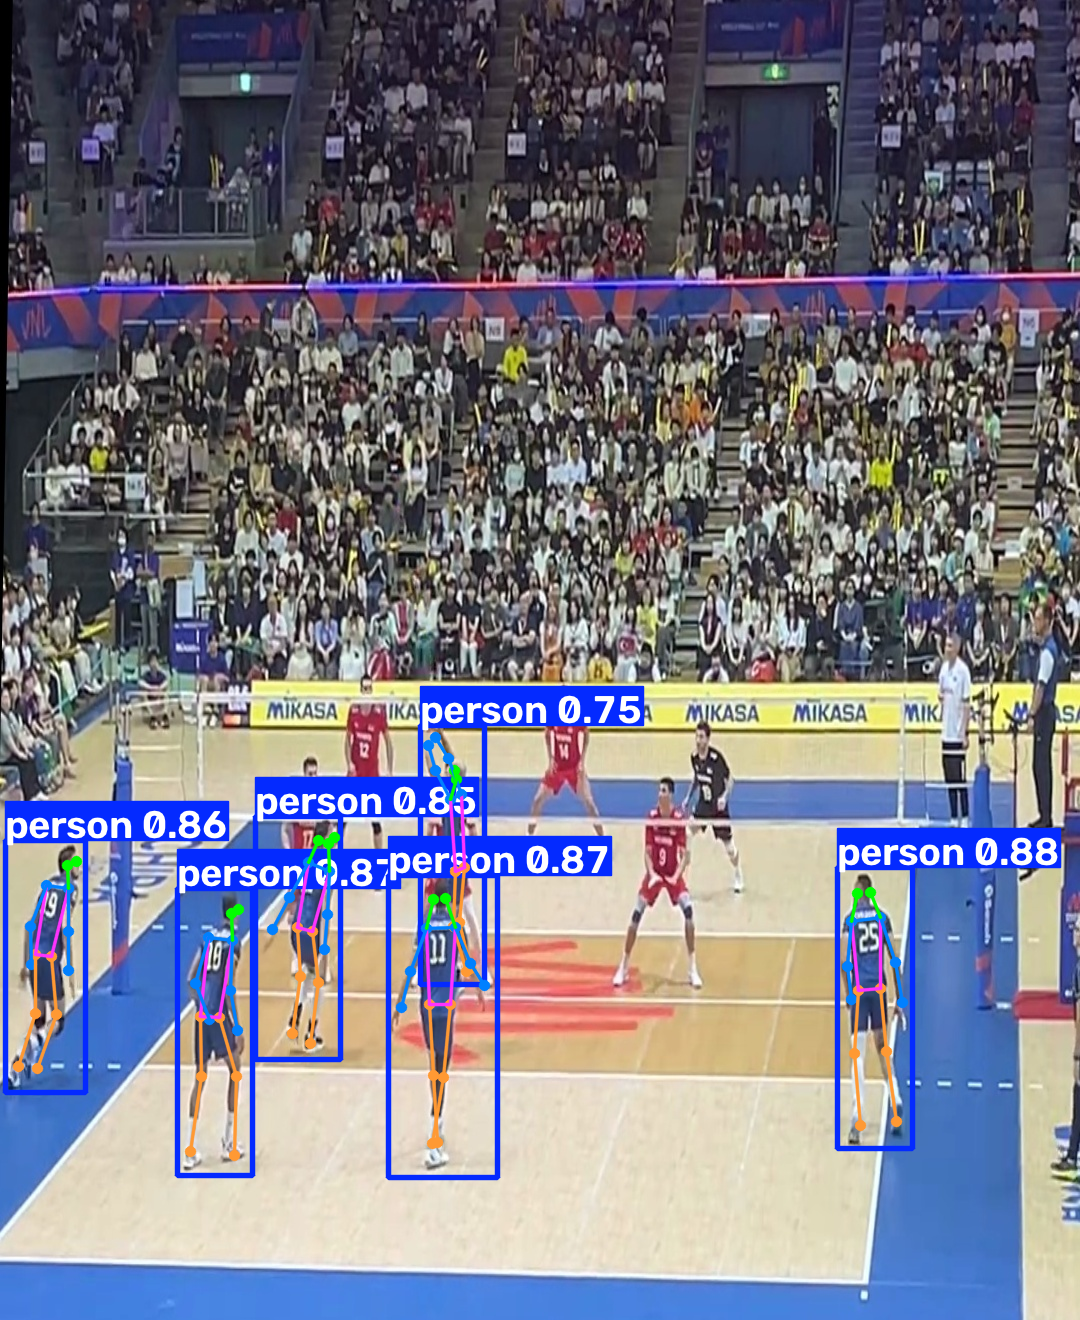

In [35]:
result = results[9]
result.show()  # display to screen
keypoints = result.keypoints

# スコアの確認

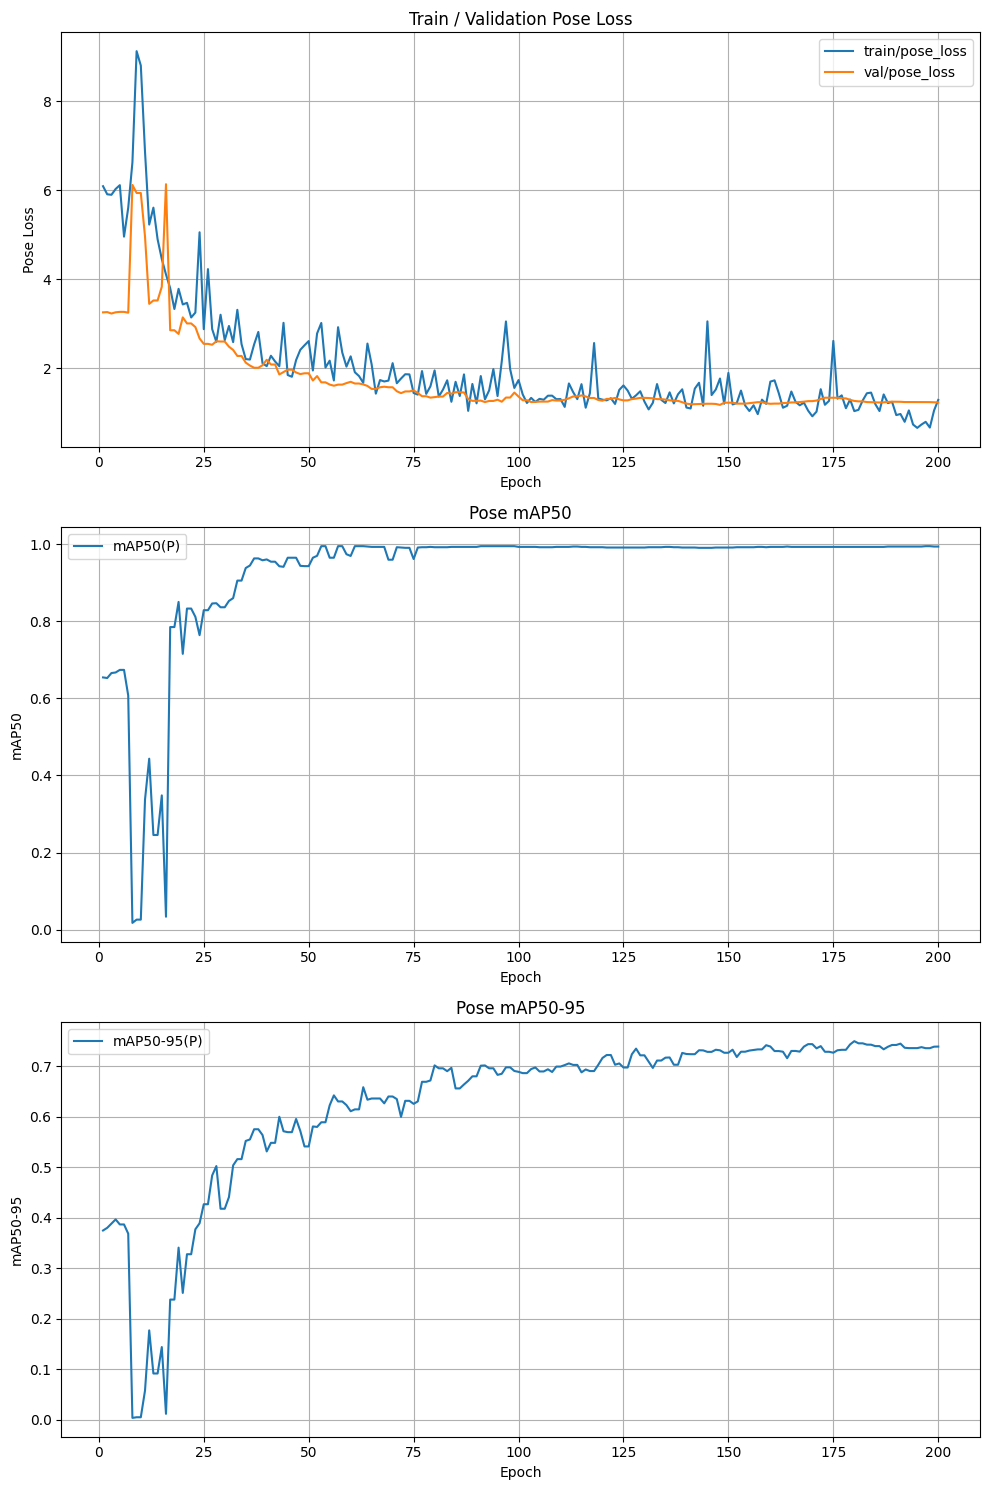

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# results.csvを読み込み
df = pd.read_csv("/content/drive/MyDrive/VNL2025/runs/pose/train-2/results.csv")

# 前後の空白を削除
df.columns = df.columns.str.strip()

# 3つのsubplotを縦に配置
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# =============================
# ① Train / Val Pose Loss
# =============================
axes[0].plot(
    df["epoch"],
    df["train/pose_loss"],
    label="train/pose_loss"
)

axes[0].plot(
    df["epoch"],
    df["val/pose_loss"],
    label="val/pose_loss"
)

axes[0].set_title("Train / Validation Pose Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Pose Loss")
axes[0].legend()
axes[0].grid(True)


# =============================
# ② mAP50(P)
# =============================
axes[1].plot(
    df["epoch"],
    df["metrics/mAP50(P)"],
    label="mAP50(P)"
)

axes[1].set_title("Pose mAP50")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP50")
axes[1].legend()
axes[1].grid(True)


# =============================
# ③ mAP50-95(P)
# =============================
axes[2].plot(
    df["epoch"],
    df["metrics/mAP50-95(P)"],
    label="mAP50-95(P)"
)

axes[2].set_title("Pose mAP50-95")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("mAP50-95")
axes[2].legend()
axes[2].grid(True)


plt.tight_layout()
plt.show()